✓ Imports OK
  Data file : Dagny_siO2_test2 copy.txt
  ΔHf(In)   = 28.51 J/g = 28.51 µJ/µg
  Tm(In)    = 156.6 °C
  β         = 200.0 K/s
  In window : 130.0 – 185.0 °C
  MC draws  : 5,000
  Output    : /Users/lauren.dagny/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/NonProliferation/July22_indium_data/results/

── Loading: Dagny_siO2_test2 copy.txt ──
  Seg id  12  (file order 0)  cooling    800.00 →    20.02 °C   39,000 rows
  Seg id  10  (file order 1)  heating     20.00 →   799.98 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
  Seg id   9  (file order 2)  cooling    800.00 →    20.02 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
  Seg id   7  (file order 3)  heating     20.00 →   799.98 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
  Seg id   6  (file order 4)  cooling    800.00 →    20.02 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
  Seg id   4  (file order 5)  heating     20.00 →   799.98 °C   39,000 rows  ⚠ mass = 0.0

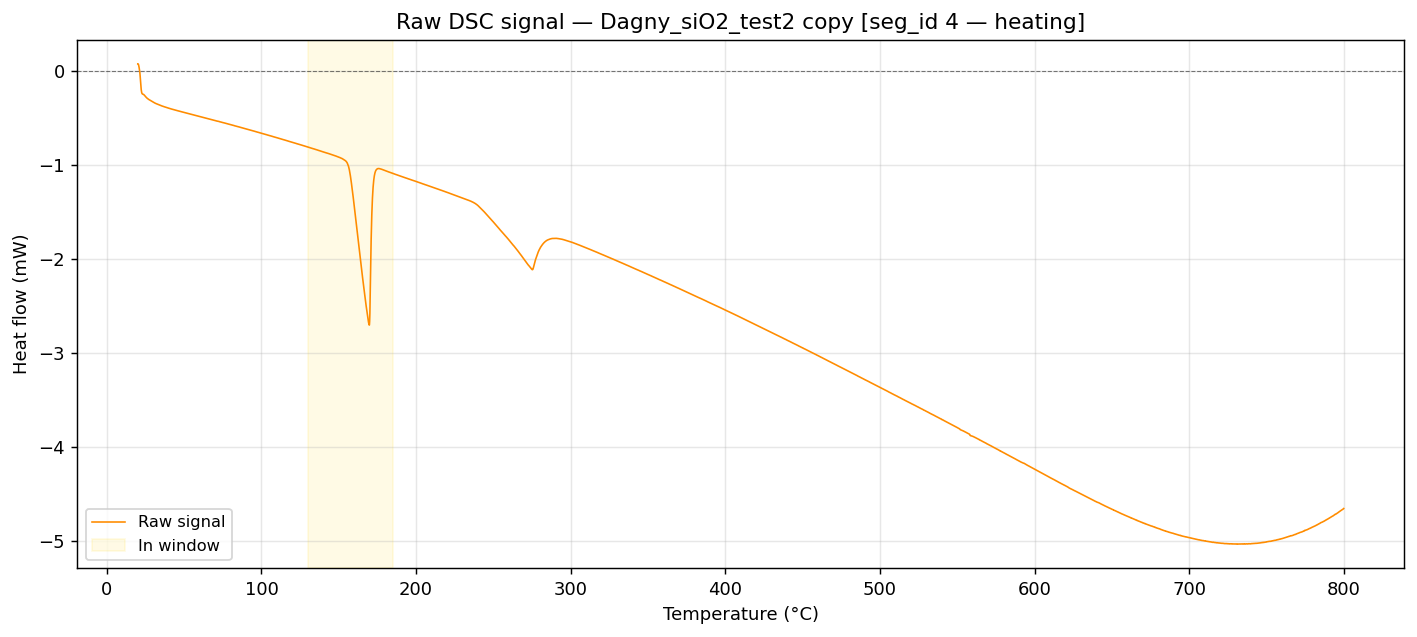


════════════════════════════════════════════════════════════════
  SEGMENT 0  |  Dagny_siO2_test2 copy [seg_id 4 — heating]
════════════════════════════════════════════════════════════════

  MC boundary summary
  Bound     Median      1σ  95 % CI
  ────────────────────────────────────────────────────
  ll       142.54°  ±1.15°  [140.68, 144.48]°
  lr       157.59°  ±1.15°  [155.67, 159.47]°
  rl       172.67°  ±1.15°  [170.75, 174.54]°
  rr       187.69°  ±1.17°  [185.74, 189.56]°

  ┌── Mass — Segment 0 ──────────────────────────────────────────
  │  Hook Method  :  2.27810 µg  ±0.13243  95 %CI [1.97128, 2.44915]
  └──────────────────────────────────────────────────────────


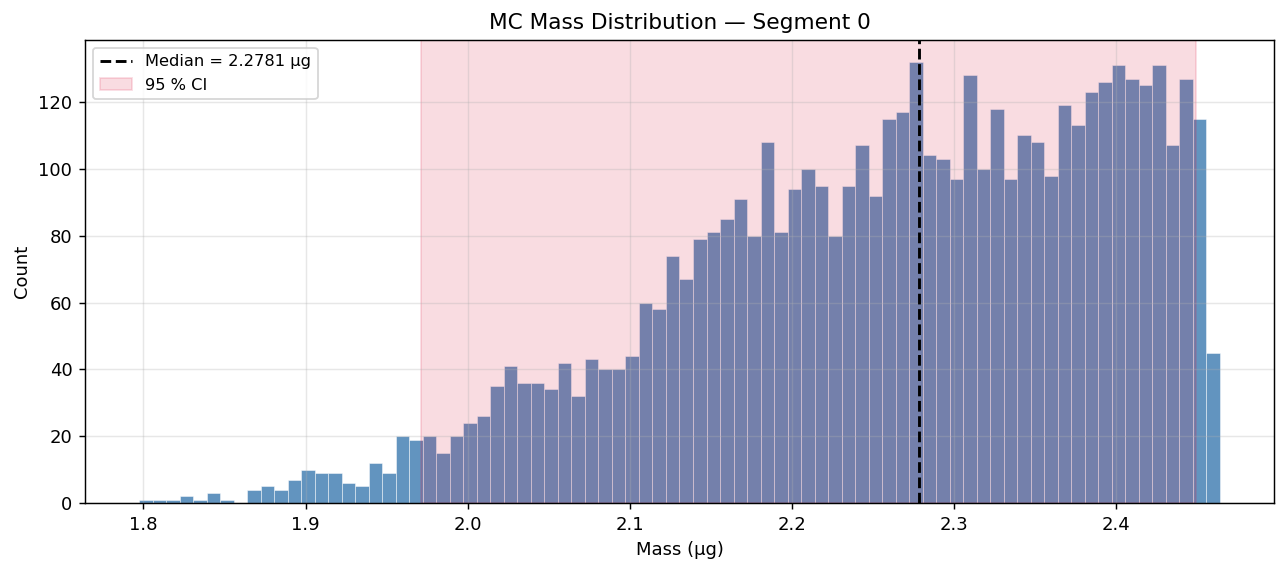

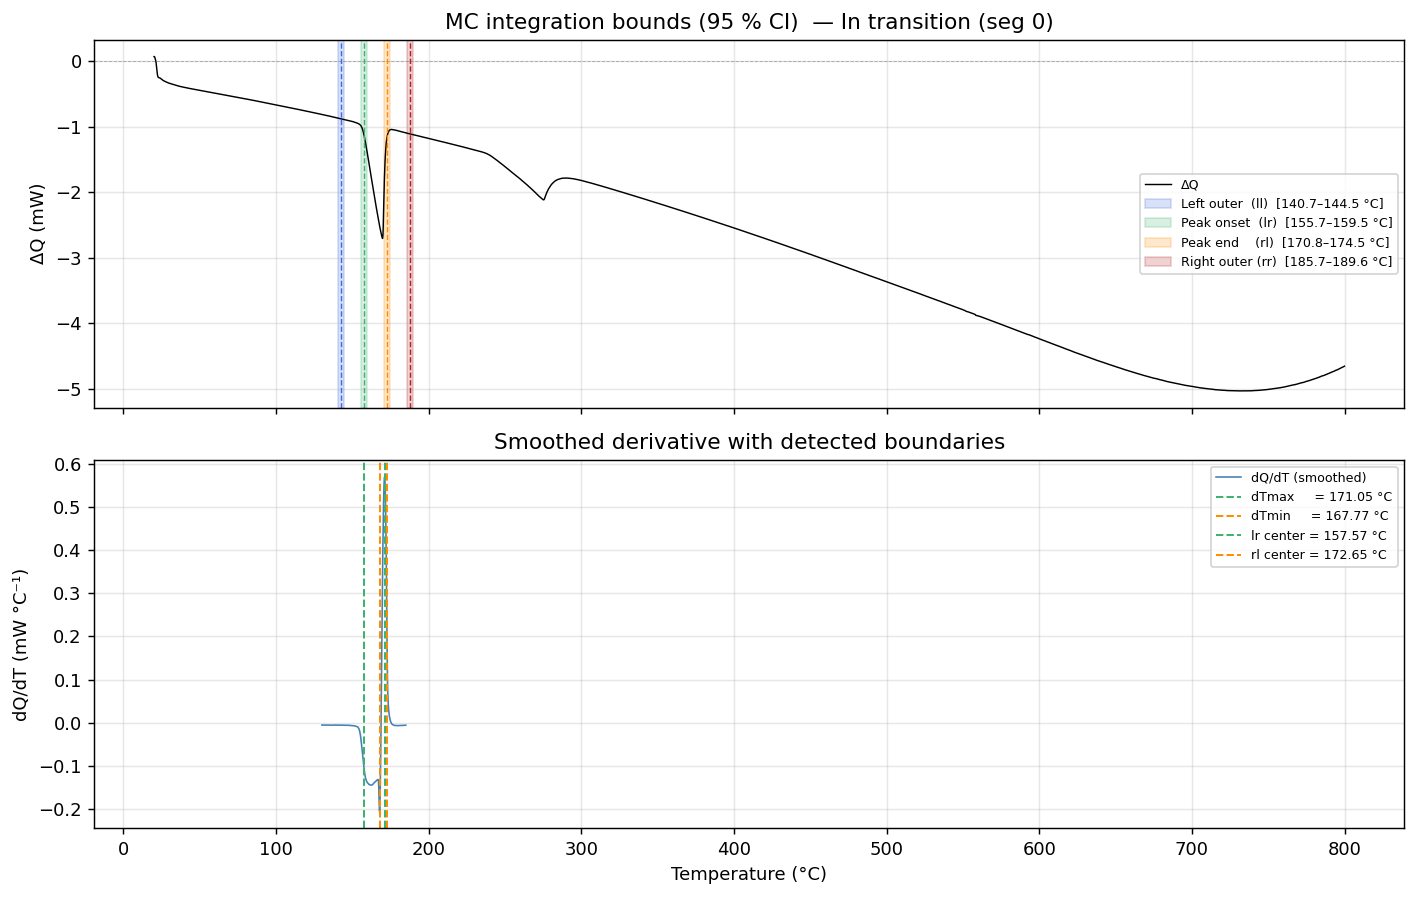


════════════════════════════════════════════════════════════════
  SEGMENT 1  |  Dagny_siO2_test2 copy [seg_id 7 — heating]
════════════════════════════════════════════════════════════════

  MC boundary summary
  Bound     Median      1σ  95 % CI
  ────────────────────────────────────────────────────
  ll       142.69°  ±1.17°  [140.77, 144.60]°
  lr       157.72°  ±1.15°  [155.80, 159.59]°
  rl       172.56°  ±1.15°  [170.62, 174.40]°
  rr       187.48°  ±1.15°  [185.62, 189.41]°

  ┌── Mass — Segment 1 ──────────────────────────────────────────
  │  Hook Method  :  2.28123 µg  ±0.13068  95 %CI [1.97487, 2.44600]
  └──────────────────────────────────────────────────────────


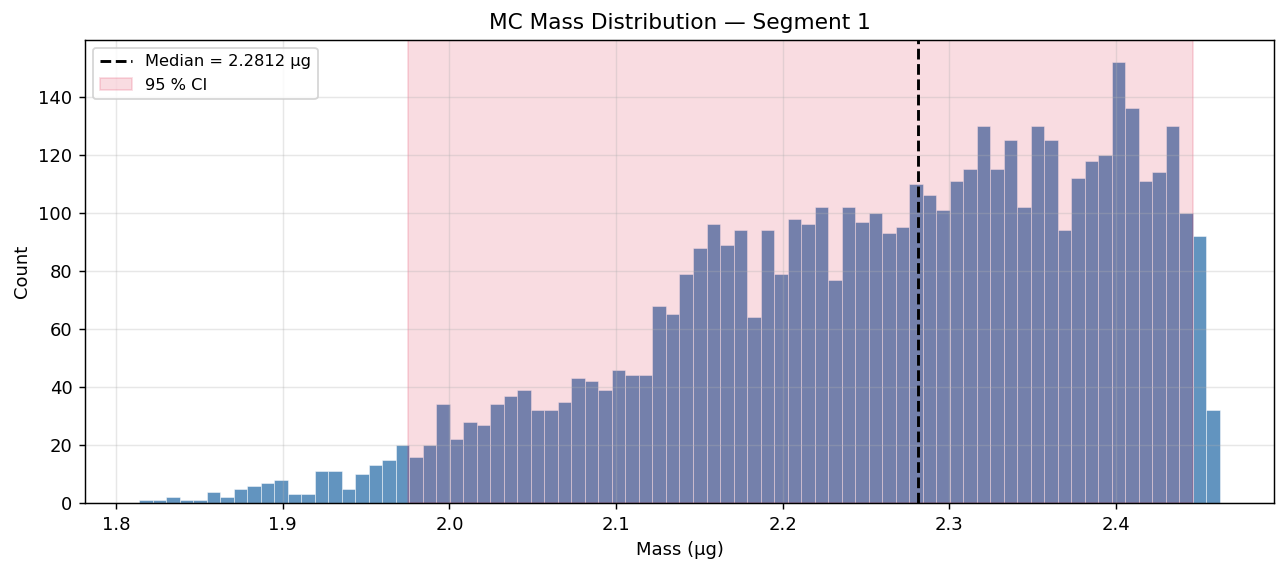

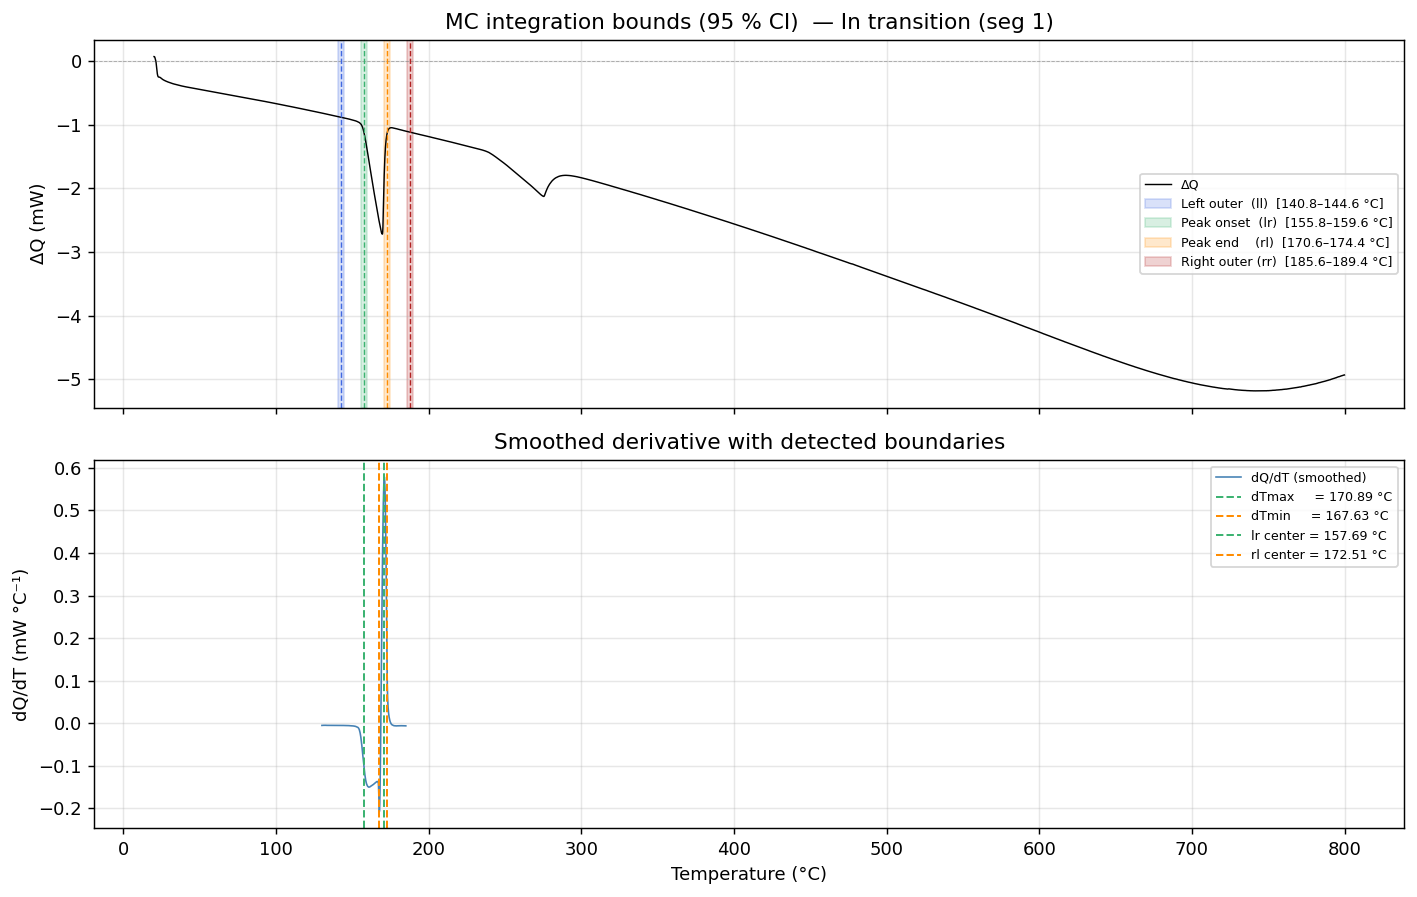


════════════════════════════════════════════════════════════════
  SEGMENT 2  |  Dagny_siO2_test2 copy [seg_id 10 — heating]
════════════════════════════════════════════════════════════════

  MC boundary summary
  Bound     Median      1σ  95 % CI
  ────────────────────────────────────────────────────
  ll       142.71°  ±1.16°  [140.80, 144.59]°
  lr       157.65°  ±1.16°  [155.80, 159.57]°
  rl       172.33°  ±1.16°  [170.46, 174.27]°
  rr       187.33°  ±1.15°  [185.46, 189.25]°

  ┌── Mass — Segment 2 ──────────────────────────────────────────
  │  Hook Method  :  2.27946 µg  ±0.13182  95 %CI [1.97489, 2.44656]
  └──────────────────────────────────────────────────────────


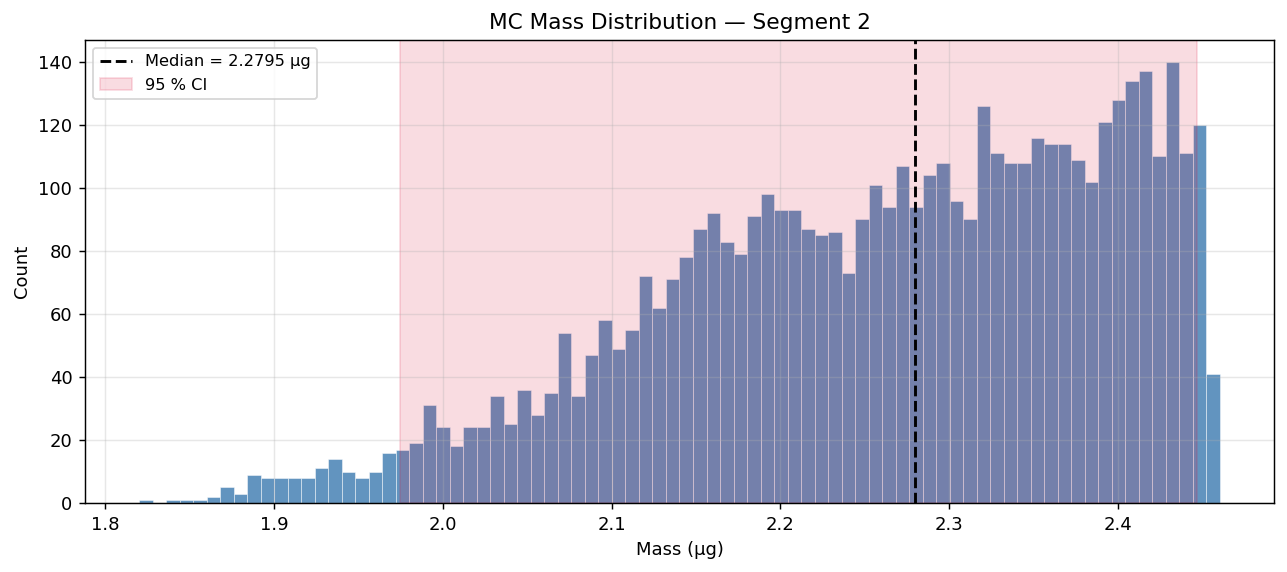

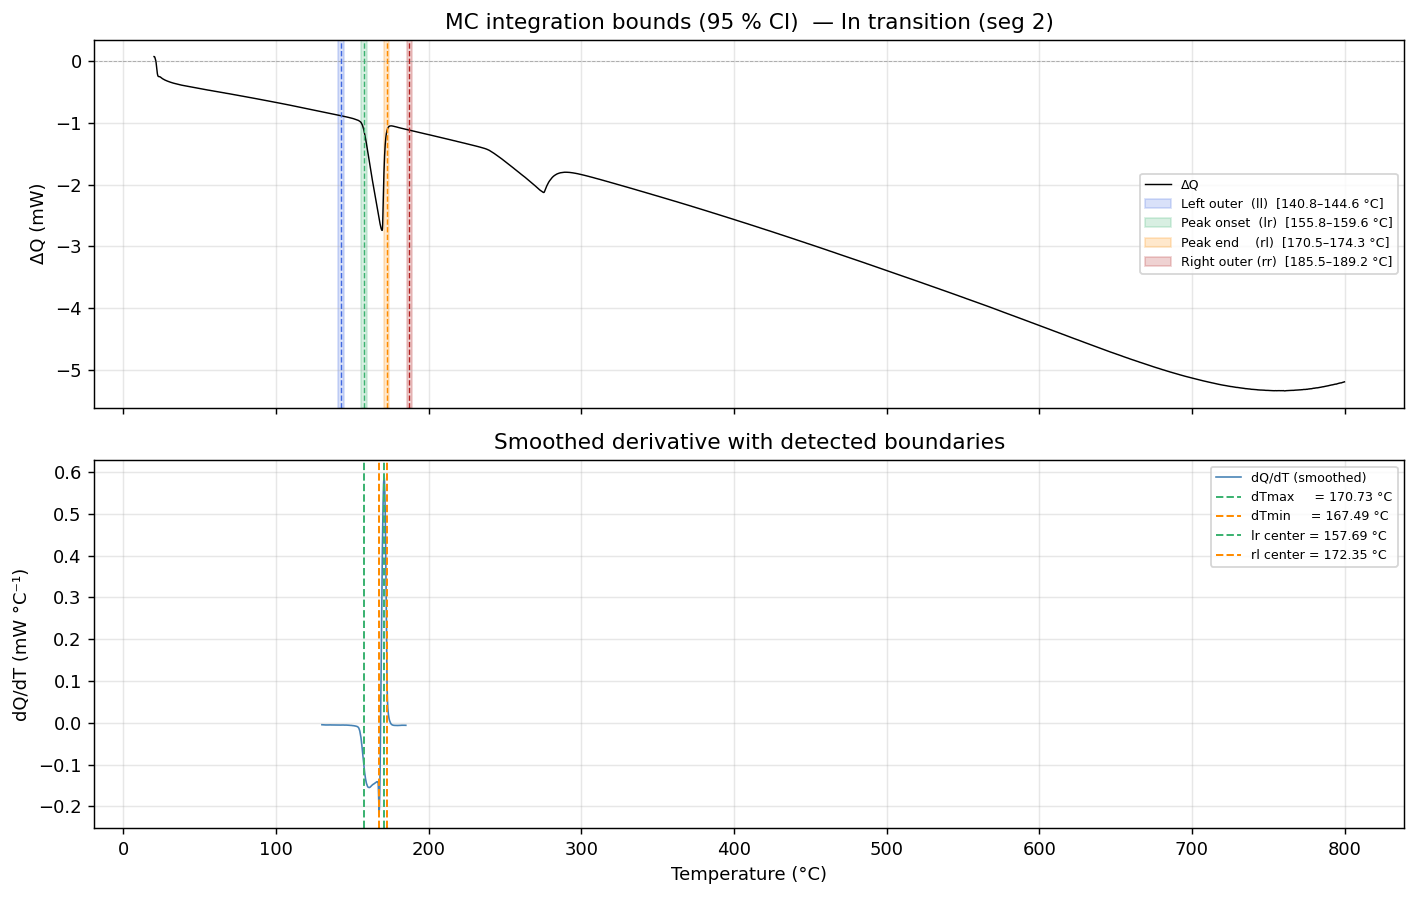


════════════════════════════════════════════════════════════════════════════════
  INDIUM MASS RECORD — HOOK METHOD
════════════════════════════════════════════════════════════════════════════════
 segment direction mass_hook_med_µg mass_hook_std_µg
       0   heating          2.27810          0.13243
       1   heating          2.28123          0.13068
       2   heating          2.27946          0.13182

  ✓ Full record saved → /Users/lauren.dagny/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/NonProliferation/July22_indium_data/results/indium_mass_record.csv

════════════════════════════════════════════════════════════════════════
  FINAL INDIUM MASS SUMMARY
════════════════════════════════════════════════════════════════════════

  Method                  Grand mean (µg)   Inter-seg σ   Mean MC σ
  ─────────────────────────────────────────────────────────────────
  Hook Method                     2.27959       0.00128     0.13164
  ───────────────────────────────

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  MC_Indium_Mass_SingleRun.ipynb                                          ║
# ║  Monte Carlo mass determination from Flash DSC data (ONE file)           ║
# ║  Method  : Hook Method (two-tangent baseline)                            ║
# ║  Ref     : ΔHf(In) = 28.51 J/g = 28.51 µJ/µg  |  Tm(In) = 156.60 °C     ║
# ║  β = 200 K/s                                                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ==============================================================================
# CELL 1 — Imports
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal      import savgol_filter, medfilt
from scipy.interpolate import interp1d
from io                import StringIO
from pathlib           import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
print("✓ Imports OK")

# ==============================================================================
# CELL 2 — Configuration (SINGLE FILE)
# ==============================================================================
# ── File path ────────────────────────────────────────────────────────────────
DATA_PATH = Path(
    "/Users/lauren.dagny/Library/CloudStorage/"
    "OneDrive-MassachusettsInstituteofTechnology/NonProliferation/"
    "July22_indium_data/Dagny_siO2_test2 copy.txt"
)

OUTPUT_DIR = DATA_PATH.parent / "results"
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Physical constants ────────────────────────────────────────────────────────
DELTA_HF  = 28.51    # J/g = µJ/µg  (NIST value for indium)
T_MELT    = 156.60   # °C
BETA      = 200.0    # K/s
N_MC      = 5_000    # Monte Carlo draws per segment

# ── Temperature window for In peak (°C) ───────────────────────────────────────
IN_WINDOW = (130.0, 185.0)

print(f"  Data file : {DATA_PATH.name}")
print(f"  ΔHf(In)   = {DELTA_HF} J/g = {DELTA_HF} µJ/µg")
print(f"  Tm(In)    = {T_MELT} °C")
print(f"  β         = {BETA} K/s")
print(f"  In window : {IN_WINDOW[0]} – {IN_WINDOW[1]} °C")
print(f"  MC draws  : {N_MC:,}")
print(f"  Output    : {OUTPUT_DIR}/")

# ==============================================================================
# ==============================================================================
# CELL 3 — Parser (Mettler-Toledo STARe format)
# ==============================================================================
import re

def parse_mettler_toledo(filepath):
    """
    Parse a Mettler-Toledo STARe multi-segment text export.

    Fixes vs. earlier version:
      - Reads as latin-1 (STARe exports are ISO-8859-1, not UTF-8 — the old
        utf-8 + errors='replace' silently mangled '°C' bytes).
      - Reads the actual column-name row after 'Curve Values:' instead of
        assuming a fixed 4-column layout. Some exports have 5 columns
        (Index, t, Ts, Tr, Value); others have 4 (Index, Ts, Tr, Value).
        Relying on a fixed `names=[...]` list is fragile — it happened to
        still work here because of a pandas index quirk, but that's an
        accident, not a guarantee.
      - Extracts the TRUE instrument segment ID from 'Curve Name:'
        (e.g. "$]12[RSPK25 500917" -> seg_id = 12) and returns segments
        sorted into chronological order. STARe exports commonly list
        segments in REVERSE order in the file (last segment first), so
        segment[0] in file order is NOT segment[0] chronologically —
        this matters a lot if you want "the first heating segment"
        (e.g. to isolate an irreversible/Wigner-type signal before it's
        annealed out in later heat/cool cycles).
      - Also pulls the sample mass out of the 'Results:' footer per
        segment and warns if it's 0.0000 mg (unset in the method), since
        a zero mass will silently poison any mass-normalized heat flow.
    """
    filepath = Path(filepath)
    with open(filepath, 'r', encoding='latin-1', errors='replace') as fh:
        lines = fh.readlines()

    cv_idx = [i for i, ln in enumerate(lines) if 'Curve Values:' in ln]
    if not cv_idx:
        raise ValueError(f"'Curve Values:' not found in {filepath.name}")

    segments = []
    for file_order, start in enumerate(cv_idx):
        # ── True instrument segment ID, from the 'Curve Name:' line above ──
        seg_id = None
        for back in range(1, 6):
            idx = start - back
            if idx < 0:
                break
            m = re.search(r'\$\]\s*(\d+)\s*\[', lines[idx])
            if m:
                seg_id = int(m.group(1))
                break
        if seg_id is None:
            seg_id = file_order  # fallback — shouldn't normally happen

        # ── Column layout: read it from the file instead of assuming it ──
        header_tokens = lines[start + 1].split()
        # header_tokens is like ['Index','t','Ts','Tr','Value'] or
        # ['Index','Ts','Tr','Value'] — either way the LAST THREE are
        # always Ts, Tr, Value in that order for STARe exports.
        if len(header_tokens) < 4:
            print(f"  ⚠ Seg (file order {file_order}, id {seg_id}): "
                  f"unexpected header {header_tokens!r} — skipping")
            continue
        n_cols = len(header_tokens)

        # ── Sample mass from the 'Results:' footer (informational) ──────
        mass_mg = None
        for back in range(1, 12):
            idx = start - back
            if idx < 0:
                break
            m = re.search(r',\s*([\d.]+)\s*mg', lines[idx])
            if m:
                mass_mg = float(m.group(1))
                break

        # ── Data rows: stop at first non-numeric row (the next footer) ──
        rows = []
        for ln in lines[start + 3:]:
            s = ln.strip()
            if not s:
                continue
            try:
                int(s.split()[0]); rows.append(s)
            except ValueError:
                break

        if not rows:
            print(f"  Seg (file order {file_order}, id {seg_id}): no data rows — {filepath.name}")
            continue

        df = pd.read_csv(
            StringIO('\n'.join(rows)),
            sep=r'\s+', header=None, names=list(range(n_cols)),
            engine='python', on_bad_lines='warn',
        )
        # Last three columns are always Ts, Tr, Value regardless of
        # whether a time column is present.
        df = df.rename(columns={n_cols - 3: 'Ts', n_cols - 2: 'Tr', n_cols - 1: 'Value'})
        for c in ('Ts', 'Tr', 'Value'):
            df[c] = pd.to_numeric(df[c], errors='coerce')
        df = df.dropna(subset=['Ts', 'Tr', 'Value']).reset_index(drop=True)

        direction = 'cooling' if df['Tr'].iloc[0] > df['Tr'].iloc[-1] else 'heating'

        mass_flag = ""
        if mass_mg is not None and mass_mg == 0.0:
            mass_flag = "  ⚠ mass = 0.0000 mg (unset in method!)"

        print(f"  Seg id {seg_id:>3}  (file order {file_order})  {direction:>7}  "
              f"{df['Tr'].iloc[0]:>8.2f} → {df['Tr'].iloc[-1]:>8.2f} °C  "
              f"{len(df):>7,} rows{mass_flag}")

        segments.append({
            'T'        : df['Tr'].values.astype(float),
            'Ts'       : df['Ts'].values.astype(float),
            'Q'        : df['Value'].values.astype(float),
            'direction': direction,
            'segment'  : file_order,   # position in file (kept for backward compat)
            'seg_id'   : seg_id,       # TRUE chronological instrument segment number
            'mass_mg'  : mass_mg,
            'label'    : f"{filepath.stem} [seg_id {seg_id} — {direction}]",
        })

    # Return in true chronological order, not file order.
    segments.sort(key=lambda s: s['seg_id'])
    return segments

# CELL 4 — Load single file
# ==============================================================================
print(f"\n── Loading: {DATA_PATH.name} ──")
segments = parse_mettler_toledo(DATA_PATH)

if not segments:
    raise RuntimeError("No segments loaded! Check file path and format.")

# ==============================================================================
# CELL 5 — Select heating segment (prefer heating for sharp In peak)
# ==============================================================================
def segs_by_dir(segs, direction):
    return [s for s in segs if s['direction'] == direction]

heat_segs = segs_by_dir(segments, 'heating')
cool_segs = segs_by_dir(segments, 'cooling')

if heat_segs:
    USE_SEGS = heat_segs
    USE_DIR = 'heating'
    print(f"\n✓ Using {len(USE_SEGS)} heating segment(s)")
else:
    USE_SEGS = cool_segs
    USE_DIR = 'cooling'
    print(f"\n⚠ Using {len(USE_SEGS)} cooling segment(s) (no heating found)")

if not USE_SEGS:
    raise RuntimeError("No segments of any direction found!")

# ==============================================================================
# CELL 6 — MC boundary detection (restricted to In peak window)
# ==============================================================================
def find_lefts_rights_mc(T, Q, n_samples=5000, seed=None,
                          peak_window=(130.0, 185.0)):
    """
    Detect the four integration bounds (ll, lr, rl, rr) around the In peak.
    Restricted to `peak_window` to avoid locking onto other features.
    """
    T = np.asarray(T, dtype=float).ravel()
    Q = np.asarray(Q, dtype=float).ravel()

    # Remove duplicate-T rows
    keep = np.concatenate(([True], np.diff(T) != 0))
    T, Q = T[keep], Q[keep]

    # Crop to search window
    win = (T >= peak_window[0]) & (T <= peak_window[1])
    Tw, Qw = T[win], Q[win]
    if len(Tw) < 50:
        print(f"  ⚠  Only {len(Tw)} pts in {peak_window} °C — skipping.")
        return None

    # Savitzky-Golay smooth + median-filter the derivative
    wlen = max(5, int(np.ceil(len(Tw) * 0.10)))
    wlen = wlen if wlen % 2 == 1 else wlen + 1
    Qsm  = savgol_filter(Qw, window_length=wlen, polyorder=3)
    dQdT = np.diff(Qsm) / np.diff(Tw)
    dQdT = medfilt(dQdT, kernel_size=5)
    Tmid = (Tw[:-1] + Tw[1:]) / 2.0

    imax  = int(np.argmax(dQdT));  imin  = int(np.argmin(dQdT))
    dTmax = float(Tmid[imax]);     dTmin = float(Tmid[imin])

    i_le = min(imax, imin)
    i_rs = max(imax, imin)

    seg_l = dQdT[:max(i_le, 1)]
    seg_r = dQdT[i_rs:] if i_rs < len(dQdT) else dQdT[-1:]

    muL, sigL = float(np.mean(seg_l)), float(np.std(seg_l))
    muR, sigR = float(np.mean(seg_r)), float(np.std(seg_r))
    if not np.isfinite(sigL) or sigL < 1e-12: sigL = max(1e-3, abs(muL) * 0.05)
    if not np.isfinite(sigR) or sigR < 1e-12: sigR = sigL

    def last_within(arr, mu, sig, m=1.0):
        idx = np.where(np.abs(arr - mu) <= sig * m)[0]
        return int(idx[-1]) if len(idx) else None

    def first_within(arr, mu, sig, m=1.0):
        idx = np.where(np.abs(arr - mu) <= sig * m)[0]
        return int(idx[0]) if len(idx) else None

    lrloc = None
    for m in range(1, 25):
        lrloc = last_within(dQdT[:max(i_le, 1)], muL, sigL, m)
        if lrloc is not None: break

    rlloc = None
    for m in range(1, 25):
        s = first_within(dQdT[i_rs:], muR, sigR, m)
        if s is not None:
            rlloc = s + i_rs; break

    if lrloc is None:
        print("  ⚠  Left boundary not found — returning None.")
        return None

    lr_cen = float(Tmid[lrloc])
    rl_cen = float(Tmid[rlloc]) if rlloc is not None else lr_cen + 20.0
    if lr_cen > rl_cen:
        lr_cen, rl_cen = rl_cen, lr_cen

    rng = np.random.default_rng(seed)
    return {
        'll'      : rng.uniform(lr_cen - 17, lr_cen - 13, n_samples),
        'lr'      : rng.uniform(lr_cen -  2, lr_cen +  2, n_samples),
        'rl'      : rng.uniform(rl_cen -  2, rl_cen +  2, n_samples),
        'rr'      : rng.uniform(rl_cen + 13, rl_cen + 17, n_samples),
        'dTmax'   : dTmax,   'dTmin'   : dTmin,
        'lrcenter': lr_cen,  'rlcenter': rl_cen,
        'T_mid'   : Tmid,    'dQdT'    : dQdT,
        'T_w'     : Tw,      'Q_w'     : Qw,
    }

# ==============================================================================
# CELL 7 — Hook baseline builder
# ==============================================================================
def hook_baseline(T, Q, t_ll, t_lr, t_rl, t_rr):
    """
    Construct a hook baseline: left tangent → linear bridge → right tangent.
    """
    ml = (T >= t_ll) & (T <= t_lr)
    if ml.sum() < 2:
        ml = (T >= t_ll - 5.0) & (T <= t_lr)

    mr = (T >= t_rl) & (T <= t_rr)
    if mr.sum() < 2:
        mr = (T >= t_rl) & (T <= t_rr + 5.0)

    p_l = (np.polyfit(T[ml], Q[ml], 1) if ml.sum() >= 2
           else np.array([0., float(np.nanmean(Q))]))
    p_r = (np.polyfit(T[mr], Q[mr], 1) if mr.sum() >= 2
           else np.array([0., float(np.nanmean(Q))]))

    Q_at_lr = np.polyval(p_l, t_lr)
    Q_at_rl = np.polyval(p_r, t_rl)
    span     = (t_rl - t_lr) or 1.0

    return np.where(
        T <= t_lr,
        np.polyval(p_l, T),
        np.where(
            T >= t_rl,
            np.polyval(p_r, T),
            Q_at_lr + (Q_at_rl - Q_at_lr) * (T - t_lr) / span
        )
    )

# ==============================================================================
# CELL 8 — Mass calculation (Hook method)
# ==============================================================================
def mass_hook(T, Q, result, beta=BETA, dhf=DELTA_HF, n=None):
    """Hook-method mass (µg) for n MC samples."""
    T, Q = np.asarray(T, float), np.asarray(Q, float)
    n    = n or len(result['ll'])
    out  = np.empty(n)
    for i in range(n):
        tll, tlr = result['ll'][i], result['lr'][i]
        trl, trr = result['rl'][i], result['rr'][i]
        mask = (T >= tll) & (T <= trr)
        if mask.sum() < 4:
            out[i] = np.nan; continue
        Ts, Qs    = T[mask], Q[mask]
        bl        = hook_baseline(Ts, Qs, tll, tlr, trl, trr)
        energy_mJ = abs(np.trapz(Qs - bl, Ts)) / beta
        out[i]    = energy_mJ * 1e3 / dhf        # µg
    return out

# ==============================================================================
# CELL 9 — Diagnostic bounds plot
# ==============================================================================
def plot_dsc_bounds(T, Q, result, title='', save_path=None):
    """Plot temperature dependence, derivative, and MC bounds."""
    if result is None:
        print("  No result — nothing to plot."); return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    styles = {
        'll': ('royalblue',      'Left outer  (ll)'),
        'lr': ('mediumseagreen', 'Peak onset  (lr)'),
        'rl': ('darkorange',     'Peak end    (rl)'),
        'rr': ('firebrick',      'Right outer (rr)'),
    }

    ax1.plot(T, Q, color='k', lw=0.8, label='ΔQ')
    ax1.axhline(0, color='grey', lw=0.5, ls='--', alpha=0.6)
    for k, (col, lbl) in styles.items():
        lo = np.percentile(result[k], 2.5); hi = np.percentile(result[k], 97.5)
        ax1.axvspan(lo, hi, alpha=0.20, color=col,
                    label=f'{lbl}  [{lo:.1f}–{hi:.1f} °C]')
        ax1.axvline(np.median(result[k]), color=col, lw=0.8, ls='--')
    ax1.set_ylabel('ΔQ (mW)')
    ax1.set_title(f'MC integration bounds (95 % CI)  {title}')
    ax1.legend(fontsize=7, loc='best'); ax1.grid(True, alpha=0.3)

    ax2.plot(result['T_mid'], result['dQdT'],
             color='steelblue', lw=0.9, label='dQ/dT (smoothed)')
    for val, col, lbl in [
        (result['dTmax'],    'mediumseagreen', f"dTmax     = {result['dTmax']:.2f} °C"),
        (result['dTmin'],    'darkorange',     f"dTmin     = {result['dTmin']:.2f} °C"),
        (result['lrcenter'], 'mediumseagreen', f"lr center = {result['lrcenter']:.2f} °C"),
        (result['rlcenter'], 'darkorange',     f"rl center = {result['rlcenter']:.2f} °C"),
    ]:
        ax2.axvline(val, color=col, lw=1.1, ls='--', label=lbl)
    ax2.set_xlabel('Temperature (°C)'); ax2.set_ylabel('dQ/dT (mW °C⁻¹)')
    ax2.set_title('Smoothed derivative with detected boundaries')
    ax2.legend(fontsize=7, loc='best'); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    return fig

# ==============================================================================
# CELL 10 — Overview plot (raw signal)
# ==============================================================================
seg0 = USE_SEGS[0]

fig, axes = plt.subplots(1, 1, figsize=(11, 5))
axes.plot(seg0['T'], seg0['Q'], color='darkorange', lw=0.9, label='Raw signal')
axes.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
axes.axvspan(*IN_WINDOW, alpha=0.10, color='gold', label='In window')
axes.set_xlabel('Temperature (°C)')
axes.set_ylabel('Heat flow (mW)')
axes.set_title(f'Raw DSC signal — {seg0["label"]}')
axes.legend(fontsize=9); axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'raw_signal.png', dpi=150, bbox_inches='tight')
plt.show()

# ==============================================================================
# CELL 11 — MC boundary detection (all segments)
# ==============================================================================
records = []

for si, seg in enumerate(USE_SEGS):
    hdr = f"  SEGMENT {si}  |  {seg['label']}"
    bar = '═' * max(len(hdr) + 4, 64)
    print(f"\n{bar}\n{hdr}\n{bar}")

    T_seg, Q_seg = seg['T'], seg['Q']

    # ── MC boundary detection ─────────────────────────────────────────────
    res = find_lefts_rights_mc(
        T_seg, Q_seg,
        n_samples=N_MC,
        seed=42 + si,
        peak_window=IN_WINDOW,
    )
    if res is None:
        print(f"  ⚠  No In peak detected in {IN_WINDOW} °C — seg {si} skipped.")
        continue

    # ── Print boundary summary ────────────────────────────────────────────
    print(f"\n  MC boundary summary")
    print(f"  {'Bound':<5}  {'Median':>9}  {'1σ':>6}  {'95 % CI'}")
    print(f"  {'─' * 52}")
    for k in ('ll', 'lr', 'rl', 'rr'):
        med = np.median(res[k]); sig = np.std(res[k])
        lo  = np.percentile(res[k], 2.5); hi = np.percentile(res[k], 97.5)
        print(f"  {k:<5}  {med:>8.2f}°  ±{sig:.2f}°  [{lo:.2f}, {hi:.2f}]°")

    # ── Compute masses ────────────────────────────────────────────────────
    mh = mass_hook(T_seg, Q_seg, res, n=N_MC)
    mh = mh[np.isfinite(mh)]

    def _stats(arr):
        return dict(med=np.median(arr), mean=np.mean(arr), std=np.std(arr),
                    lo=np.percentile(arr, 2.5), hi=np.percentile(arr, 97.5))
    sh = _stats(mh)

    # ── Store record ──────────────────────────────────────────────────────
    records.append({
        'segment'           : si,
        'direction'         : USE_DIR,
        'T_start_°C'        : float(seg['T'][0]),
        'T_end_°C'          : float(seg['T'][-1]),
        'lr_center_°C'      : res['lrcenter'],
        'rl_center_°C'      : res['rlcenter'],
        'mass_hook_med_µg'  : sh['med'],
        'mass_hook_std_µg'  : sh['std'],
        'mass_hook_p025_µg' : sh['lo'],
        'mass_hook_p975_µg' : sh['hi'],
    })

    # ── Console summary ───────────────────────────────────────────────────
    print(f"\n  ┌── Mass — Segment {si} {'─' * 42}")
    print(f"  │  Hook Method  :  {sh['med']:.5f} µg  "
          f"±{sh['std']:.5f}  95 %CI [{sh['lo']:.5f}, {sh['hi']:.5f}]")
    print(f"  └{'─' * 58}")

    # ── MC histogram ──────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.hist(mh, bins=80, color='steelblue',
            edgecolor='white', lw=0.3, alpha=0.85)
    ax.axvline(sh['med'], color='k', lw=1.6, ls='--',
               label=f"Median = {sh['med']:.4f} µg")
    ax.axvspan(sh['lo'], sh['hi'],
               alpha=0.15, color='crimson', label='95 % CI')
    ax.set_xlabel('Mass (µg)'); ax.set_ylabel('Count')
    ax.set_title(f'MC Mass Distribution — Segment {si}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'mc_hist_seg{si}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Bounds diagnostic ─────────────────────────────────────────────────
    plot_dsc_bounds(
        T_seg, Q_seg, res,
        title=f'— In transition (seg {si})',
        save_path=OUTPUT_DIR / f'bounds_seg{si}.png',
    )
    plt.show()

# ==============================================================================
# CELL 12 — Results DataFrame & CSV export
# ==============================================================================
df = pd.DataFrame(records)

print("\n" + "═" * 80)
print("  INDIUM MASS RECORD — HOOK METHOD")
print("═" * 80)

if not df.empty:
    show = ['segment', 'direction', 'mass_hook_med_µg', 'mass_hook_std_µg']
    fmt  = {c: '{:.5f}'.format for c in show if 'mass' in c}
    print(df[show].to_string(index=False, formatters=fmt))

CSV_PATH = OUTPUT_DIR / 'indium_mass_record.csv'
df.to_csv(CSV_PATH, index=False)
print(f"\n  ✓ Full record saved → {CSV_PATH}")

# ==============================================================================
# CELL 13 — Final summary
# ==============================================================================
print("\n" + "═" * 72)
print("  FINAL INDIUM MASS SUMMARY")
print("═" * 72)

if not df.empty:
    mh_arr = df['mass_hook_med_µg'].values
    sh_arr = df['mass_hook_std_µg'].values

    print(f"\n  {'Method':<22} {'Grand mean (µg)':>16}"
          f"  {'Inter-seg σ':>12}  {'Mean MC σ':>10}")
    print(f"  {'─' * 65}")
    print(f"  {'Hook Method':<22} {np.mean(mh_arr):>16.5f}"
          f"  {np.std(mh_arr):>12.5f}  {np.mean(sh_arr):>10.5f}")
    print(f"  {'─' * 65}")
    print(f"\n  Physical constants used:")
    print(f"    ΔHf(In) = {DELTA_HF} J/g = {DELTA_HF} µJ/µg")
    print(f"    β       = {BETA} K/s")
    print(f"    Tm(In)  = {T_MELT} °C")
    print(f"\n  ✓ CSV  → {CSV_PATH}")
    print(f"  ✓ PNGs → {OUTPUT_DIR}/")

print("\n" + "═" * 72)

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 12 — Load SiO₂+In composite sample
# ════════════════════════════════════════════════════════════════════════════
# Update this path to your SiO₂+In file
COMPOSITE_PATH = Path(
    "/Users/lauren.dagny/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/NonProliferation/July22_indium_data/Dagny_SiO2_test_withSiO2.txt"
)

print(f"\n── Loading composite (SiO₂+In): {COMPOSITE_PATH.name} ──")
composite_segs = parse_mettler_toledo(COMPOSITE_PATH)

if not composite_segs:
    raise RuntimeError("No segments loaded from composite file!")

# Select heating segments (prefer heating like before)
comp_heat = segs_by_dir(composite_segs, 'heating')
comp_cool = segs_by_dir(composite_segs, 'cooling')

if comp_heat:
    COMP_SEGS = comp_heat
    print(f"✓ Using {len(COMP_SEGS)} composite heating segment(s), chronological order: "
          f"{[s['seg_id'] for s in COMP_SEGS]}")
else:
    COMP_SEGS = comp_cool
    print(f"⚠ Using {len(COMP_SEGS)} composite cooling segment(s), chronological order: "
          f"{[s['seg_id'] for s in COMP_SEGS]}")

if not COMP_SEGS:
    raise RuntimeError("No composite segments found!")

# ── Which heat/cool cycle to analyze ─────────────────────────────────────
# 0 = the TRUE first cycle (chronologically) — the only one that can show
#     an irreversible/Wigner-type signal, since it hasn't been annealed by
#     a prior heat yet. Later cycles (1, 2, 3...) are effectively repeat
#     baselines once that energy has been released.
CYCLE_INDEX = 0

comp_seg = COMP_SEGS[CYCLE_INDEX]
print(f"\n  Selected cycle {CYCLE_INDEX} → seg_id {comp_seg['seg_id']}: {comp_seg['label']}")
if CYCLE_INDEX != 0:
    print(f"  ⚠ Not using the first chronological cycle — this will include any "
          f"annealing from earlier cycles.")


── Loading composite (SiO₂+In): Dagny_SiO2_test_withSiO2.txt ──
  Seg id  12  (file order 0)  cooling    800.00 →    20.02 °C   39,000 rows
  Seg id  10  (file order 1)  heating     20.00 →   799.98 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
  Seg id   9  (file order 2)  cooling    800.00 →    20.02 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
  Seg id   7  (file order 3)  heating     20.00 →   799.98 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
  Seg id   6  (file order 4)  cooling    800.00 →    20.02 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
  Seg id   4  (file order 5)  heating     20.00 →   799.98 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
  Seg id   3  (file order 6)  cooling    800.00 →    20.02 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
  Seg id   1  (file order 7)  heating     20.00 →   799.98 °C   39,000 rows  ⚠ mass = 0.0000 mg (unset in method!)
✓ Using 4 composite heating segment(s), chronological 

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 13 — Multi-peak detector
# ════════════════════════════════════════════════════════════════════════════
def find_multiple_peaks(T, Q, n_peaks=4, peak_window=(20.0, 800.0),
                        prominence_pct=5, smooth_width_degC=15.0):
    """
    Detect multiple peaks in the dQ/dT signal.

    Parameters
    ----------
    T, Q : arrays
        Temperature and heat flow
    n_peaks : int
        Expected number of peaks (only affects minimum spacing enforced
        between detected peaks, via `distance` in find_peaks)
    peak_window : tuple
        (T_min, T_max) for searching
    prominence_pct : float
        Prominence threshold as % of signal range
    smooth_width_degC : float
        Savitzky-Golay smoothing width in °C (NOT a fraction of the window's
        point count — see note below).

    Returns
    -------
    dict with peaks list, each containing:
        - T_center, Q_center, prominence, peak_index

    NOTE on smoothing width — this used to be `wlen = 10% of len(Tw)`, i.e.
    the smoothing width scaled with however wide `peak_window` was. That's
    fine as long as you never change the window, but it silently breaks
    peak resolution the moment you do: widening the window from e.g.
    (50,200)°C to (20,800)°C multiplies the point count ~5x, which balloons
    the smoothing width from ~15°C to ~75°C+ — wide enough to blur out and
    mislocate a sharp transition like the In melt (it shifted the detected
    In peak from 171°C to a biased ~194°C in testing). Fixing the smoothing
    width in physical °C terms, independent of the search window, means you
    can widen `peak_window` freely without silently degrading resolution.
    """
    from scipy.signal import find_peaks

    T = np.asarray(T, float)
    Q = np.asarray(Q, float)

    # Crop to window
    win = (T >= peak_window[0]) & (T <= peak_window[1])
    Tw, Qw = T[win], Q[win]

    # Smooth — fixed physical width, not a fraction of the window's point count
    spacing = float(np.mean(np.diff(Tw))) if len(Tw) > 1 else 1.0
    wlen = max(5, int(round(smooth_width_degC / spacing)))
    wlen = wlen if wlen % 2 == 1 else wlen + 1
    wlen = min(wlen, len(Tw) - 1 if len(Tw) % 2 == 0 else len(Tw) - 2)
    wlen = max(wlen, 5)
    Qsm = savgol_filter(Qw, window_length=wlen, polyorder=3)

    # Find peaks in the derivative (dQ/dT)
    dQdT = np.diff(Qsm) / np.diff(Tw)
    Tmid = (Tw[:-1] + Tw[1:]) / 2.0

    # Set prominence threshold
    prom_thresh = np.ptp(dQdT) * (prominence_pct / 100.0)

    peaks_idx, props = find_peaks(
        dQdT,
        prominence=prom_thresh,
        distance=max(1, len(dQdT) // (n_peaks + 1))
    )

    peaks = []
    for idx in peaks_idx:
        if 0 <= idx < len(Tmid):
            peaks.append({
                'T_center': float(Tmid[idx]),
                'dQdT_max': float(dQdT[idx]),
                'prominence': float(props['prominences'][len(peaks)]),
                'peak_index': idx,
            })

    # Sort by temperature
    peaks = sorted(peaks, key=lambda x: x['T_center'])

    return {
        'peaks': peaks,
        'T_mid': Tmid,
        'dQdT': dQdT,
        'T_window': Tw,
        'Q_smooth': Qsm,
        'smooth_wlen': wlen,
    }

# Detect peaks in composite sample — full ramp range (20-800°C), not just
# the In window, so any SiO2/Wigner feature anywhere in the scan gets caught.
print("\n✓ Detecting peaks in composite (SiO₂+In) sample...")
comp_result = find_multiple_peaks(
    comp_seg['T'], comp_seg['Q'],
    n_peaks=4,
    peak_window=(20.0, 800.0),
    prominence_pct=5,
    smooth_width_degC=15.0,
)

print(f"  (smoothing window: {comp_result['smooth_wlen']} points ≈ 15°C)")
print(f"\n  Found {len(comp_result['peaks'])} peaks:")
for i, pk in enumerate(comp_result['peaks']):
    print(f"    Peak {i}: T = {pk['T_center']:>7.2f}°C, dQdT_max = {pk['dQdT_max']:>7.3f} mW/°C")



✓ Detecting peaks in composite (SiO₂+In) sample...
  (smoothing window: 751 points ≈ 15°C)

  Found 2 peaks:
    Peak 0: T =  171.19°C, dQdT_max =   0.221 mW/°C
    Peak 1: T =  481.25°C, dQdT_max =   0.138 mW/°C


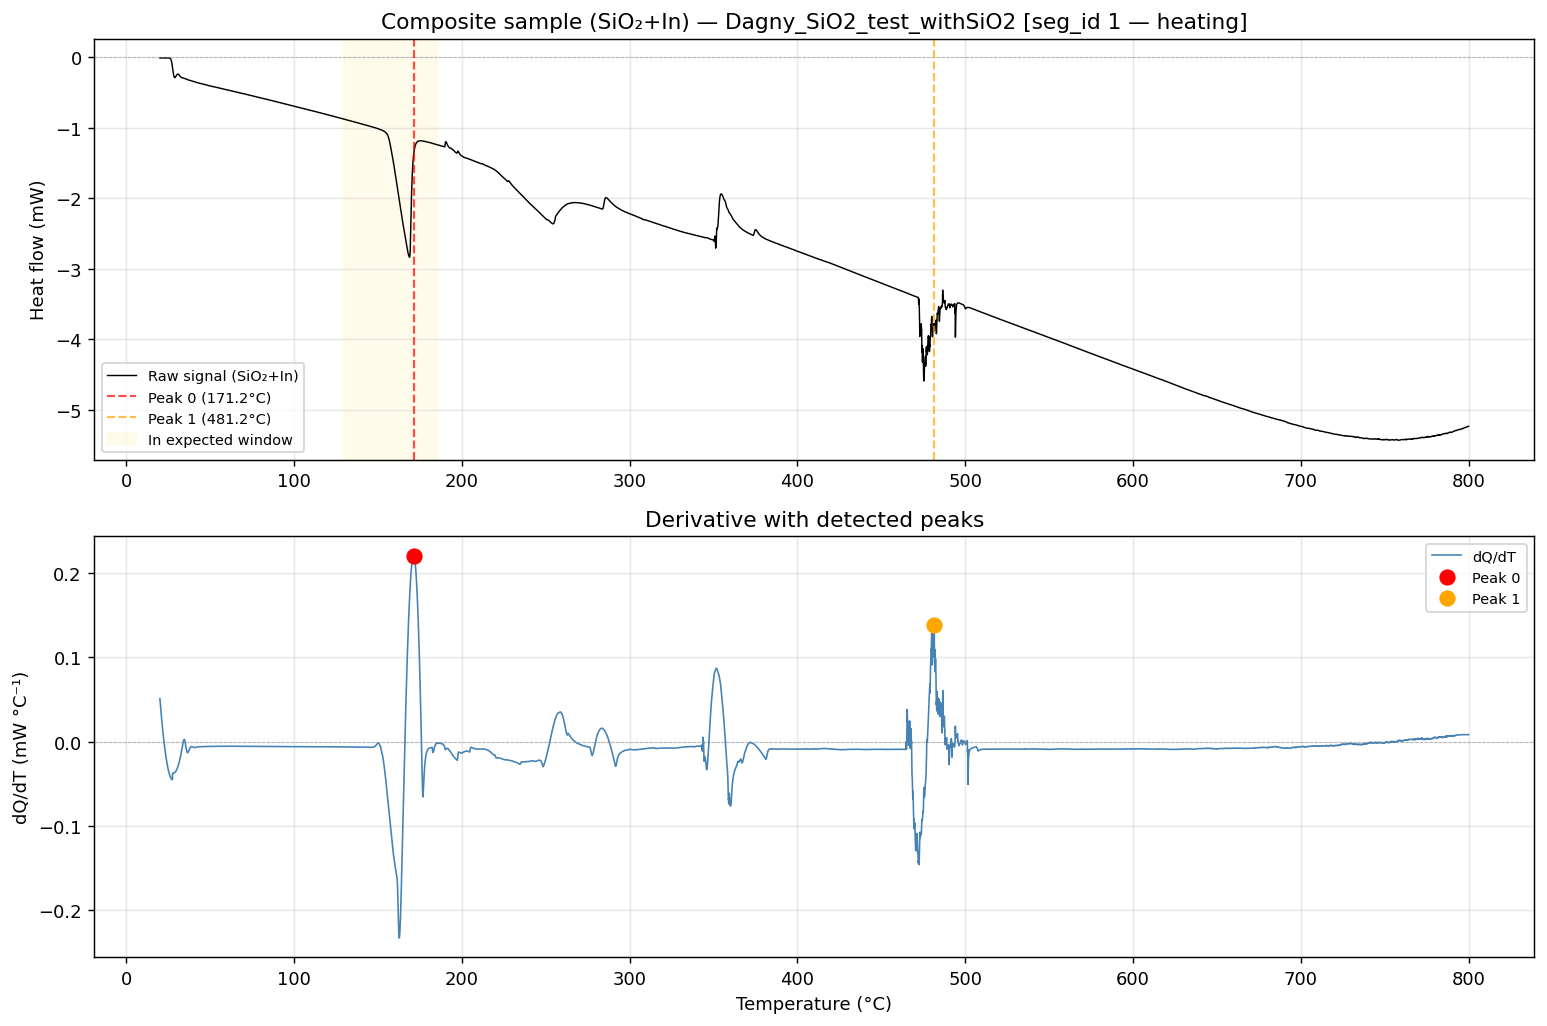


✓ Peak visualization saved


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 14 — Visualize all 4 peaks
# ════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Panel 1: Raw signal with peaks marked
ax1.plot(comp_seg['T'], comp_seg['Q'], 'k-', lw=0.8, label='Raw signal (SiO₂+In)')
ax1.axhline(0, color='grey', lw=0.5, ls='--', alpha=0.5)
colors = ['red', 'orange', 'green', 'blue', 'purple']
for i, pk in enumerate(comp_result['peaks']):
    ax1.axvline(pk['T_center'], color=colors[i % len(colors)],
                lw=1.2, ls='--', alpha=0.7, label=f"Peak {i} ({pk['T_center']:.1f}°C)")
ax1.axvspan(*IN_WINDOW, alpha=0.08, color='gold', label='In expected window')
ax1.set_ylabel('Heat flow (mW)')
ax1.set_title(f'Composite sample (SiO₂+In) — {comp_seg["label"]}')
ax1.legend(fontsize=8, loc='best'); ax1.grid(True, alpha=0.3)

# Panel 2: dQ/dT with peaks
ax2.plot(comp_result['T_mid'], comp_result['dQdT'], 'steelblue', lw=0.9, label='dQ/dT')
ax2.axhline(0, color='grey', lw=0.5, ls='--', alpha=0.5)
for i, pk in enumerate(comp_result['peaks']):
    ax2.plot(pk['T_center'], pk['dQdT_max'], 'o', color=colors[i % len(colors)],
             markersize=8, label=f"Peak {i}")
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('dQ/dT (mW °C⁻¹)')
ax2.set_title('Derivative with detected peaks')
ax2.legend(fontsize=8, loc='best'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'composite_peaks_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Peak visualization saved")

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 15 — Identify In peak in composite (match by window, not position)
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 72)
print("  IDENTIFYING IN PEAK IN COMPOSITE SAMPLE")
print("═" * 72)

# Pure In peak center (from first sample)
pure_in_T = records[0]['lr_center_°C'] if records else T_MELT

print(f"\n  Pure In sample:")
print(f"    Peak center (onset): {pure_in_T:.2f}°C")
print(f"    Expected range: {IN_WINDOW[0]}–{IN_WINDOW[1]}°C")

# NOTE: the old version assumed the In peak was always "whichever peak isn't
# first" (skip Peak 0). That assumption doesn't hold in general — e.g. this
# is a pre-irradiation baseline/control run, and unirradiated SiO2 has no
# stored energy to release, so there's legitimately only ONE peak (the In
# calibration standard itself) with no separate SiO2 signal to skip past.
# Selecting by proximity to the known In window/pure-In temperature, rather
# than by position in the peaks list, works whether there are 1, 2, or more
# peaks present.

candidate_peaks = list(enumerate(comp_result['peaks']))

if not candidate_peaks:
    raise ValueError(
        f"No peaks detected at all in the composite signal's search window "
        f"({comp_result['T_window'][0]:.0f}–{comp_result['T_window'][-1]:.0f}°C). "
        f"Check comp_seg / prominence_pct in Cell 13 before proceeding."
    )

valid_peaks = [(idx, pk) for idx, pk in candidate_peaks
               if IN_WINDOW[0] <= pk['T_center'] <= IN_WINDOW[1]]

if valid_peaks:
    in_peak_idx, in_peak_composite = min(valid_peaks, key=lambda x: abs(x[1]['T_center'] - pure_in_T))
    IN_PEAK_IN_WINDOW = True
else:
    in_peak_idx, in_peak_composite = min(candidate_peaks, key=lambda x: abs(x[1]['T_center'] - pure_in_T))
    IN_PEAK_IN_WINDOW = False
    print(f"  ⚠ No candidate peak fell in {IN_WINDOW}°C — using nearest (Peak {in_peak_idx} @ {in_peak_composite['T_center']:.2f}°C)")

IN_PEAK_IDX = in_peak_idx
IN_PEAK_T = in_peak_composite['T_center']

if len(comp_result['peaks']) == 1:
    print(f"\n  ℹ Only 1 peak detected — treating it as the In peak, SiO₂ signal = 0.")
    print(f"    (Expected for an unirradiated/pre-irradiation control: no stored")
    print(f"    energy, so no extra exotherm beyond the In calibration standard.)")

print(f"\n  ✓ Selected: Peak {IN_PEAK_IDX} @ T = {IN_PEAK_T:.2f}°C  (In peak, in-window={IN_PEAK_IN_WINDOW})")



════════════════════════════════════════════════════════════════════════
  IDENTIFYING IN PEAK IN COMPOSITE SAMPLE
════════════════════════════════════════════════════════════════════════

  Pure In sample:
    Peak center (onset): 157.57°C
    Expected range: 130.0–185.0°C

  ✓ Selected: Peak 0 @ T = 171.19°C  (In peak, in-window=True)


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 16 — Extract individual peak masses (composite)
# ════════════════════════════════════════════════════════════════════════════
def extract_peak_mass(T, Q, peak_center_T, peak_width_frac=0.20,
                      beta=BETA, dhf=DELTA_HF):
    """
    Extract the mass contribution of a single peak using MC sampling
    around a peak center.

    Parameters
    ----------
    T, Q : arrays
        Temperature and heat flow (already baseline-subtracted or raw)
    peak_center_T : float
        Temperature of peak center
    peak_width_frac : float
        Width of integration window as fraction of peak location
        (e.g., 0.20 = ±20% of peak_center_T around peak)
    beta, dhf : float
        Heating rate (K/s), enthalpy of fusion (J/g)

    Returns
    -------
    dict with mass samples and statistics
    """
    T = np.asarray(T, float)
    Q = np.asarray(Q, float)

    # Define window around peak
    window_half = peak_center_T * peak_width_frac
    T_lo = peak_center_T - window_half
    T_hi = peak_center_T + window_half

    mask = (T >= T_lo) & (T <= T_hi)
    if mask.sum() < 10:
        print(f"    ⚠ Only {mask.sum()} points in peak window — may be unreliable")
        return None

    Tp, Qp = T[mask], Q[mask]

    # Simple trapz integration (no fancy baseline within the peak window)
    energy_mJ = abs(np.trapz(Qp, Tp)) / beta
    mass_µg = energy_mJ * 1e3 / dhf

    return {
        'T_window': (T_lo, T_hi),
        'n_points': mask.sum(),
        'energy_mJ': energy_mJ,
        'mass_µg': mass_µg,
        'T_center': peak_center_T,
    }

# Extract masses for each peak in composite
print("\n" + "═" * 72)
print("  EXTRACTING PEAK MASSES FROM COMPOSITE (SiO₂+In)")
print("═" * 72)

T_comp, Q_comp = comp_seg['T'], comp_seg['Q']

peak_masses = {}
for i, pk in enumerate(comp_result['peaks']):
    result = extract_peak_mass(
        T_comp, Q_comp,
        peak_center_T=pk['T_center'],
        peak_width_frac=0.15  # ±15% window around each peak
    )

    if result:
        peak_masses[i] = result
        print(f"\n  Peak {i} (T = {pk['T_center']:.2f}°C):")
        print(f"    Window: [{result['T_window'][0]:.2f}, {result['T_window'][1]:.2f}]°C")
        print(f"    Points: {result['n_points']}")
        print(f"    Energy: {result['energy_mJ']:.4f} mJ")
        print(f"    Mass (as In): {result['mass_µg']:.5f} µg")
        if i == IN_PEAK_IDX:
            print(f"    ★★★ THIS IS THE IN PEAK ★★★")

print("\n✓ Peak mass extraction complete")


════════════════════════════════════════════════════════════════════════
  EXTRACTING PEAK MASSES FROM COMPOSITE (SiO₂+In)
════════════════════════════════════════════════════════════════════════

  Peak 0 (T = 171.19°C):
    Window: [145.51, 196.87]°C
    Points: 2568
    Energy: 0.3643 mJ
    Mass (as In): 12.77681 µg
    ★★★ THIS IS THE IN PEAK ★★★

  Peak 1 (T = 481.25°C):
    Window: [409.06, 553.44]°C
    Points: 7218
    Energy: 2.5069 mJ
    Mass (as In): 87.93088 µg

✓ Peak mass extraction complete


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 17 — Calculate SiO₂ enthalpy
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 72)
print("  SiO₂ ENTHALPY CALCULATION")
print("═" * 72)

# Pure In mass (median from first sample)
pure_in_mass_µg = records[0]['mass_hook_med_µg'] if records else np.nan
pure_in_energy_mJ = pure_in_mass_µg * DELTA_HF / 1e3

print(f"\n  Pure In sample:")
print(f"    Mass: {pure_in_mass_µg:.5f} µg")
print(f"    ΔH(In) [from mass]: {pure_in_energy_mJ:.4f} mJ")
print(f"    ΔH_f(In) ref: {DELTA_HF} J/g")

# In peak from composite
comp_in_mass_µg = peak_masses[IN_PEAK_IDX]['mass_µg']
comp_in_energy_mJ = peak_masses[IN_PEAK_IDX]['energy_mJ']

print(f"\n  Composite (SiO₂+In) — In peak:")
print(f"    Peak index: {IN_PEAK_IDX}")
print(f"    T center: {IN_PEAK_T:.2f}°C")
print(f"    Mass (as In): {comp_in_mass_µg:.5f} µg")
print(f"    ΔH (measured): {comp_in_energy_mJ:.4f} mJ")

# All other peaks = SiO₂
print(f"\n  SiO₂ peaks (all except Peak {IN_PEAK_IDX}):")
sio2_energy_mJ = 0.0
sio2_peaks = []
for i, mass_data in peak_masses.items():
    if i != IN_PEAK_IDX:
        sio2_energy_mJ += mass_data['energy_mJ']
        sio2_peaks.append(i)
        print(f"    Peak {i}: {mass_data['energy_mJ']:.4f} mJ @ {mass_data['T_center']:.2f}°C")

print(f"\n  Total SiO₂ energy: {sio2_energy_mJ:.4f} mJ")
print(f"  SiO₂ peaks: {sio2_peaks}")

# Estimate SiO₂ mass (if we knew molar mass or enthalpy)
# For now, just report the energy
# Common SiO2 transition: vitreous → crystalline is ~0.4 J/g
# But phase transitions vary; we'll report both total and per-peak

print(f"\n" + "─" * 72)
print(f"  SUMMARY:")
print(f"  ├─ Pure In energy (from mass): {pure_in_energy_mJ:.4f} mJ")
print(f"  ├─ In in composite (peak {IN_PEAK_IDX}): {comp_in_energy_mJ:.4f} mJ")
print(f"  ├─ SiO₂ total energy: {sio2_energy_mJ:.4f} mJ")
print(f"  └─ SiO₂ peaks: {sio2_peaks}")

# Estimate if In amounts changed (mass ratio)
in_mass_ratio = comp_in_mass_µg / pure_in_mass_µg if pure_in_mass_µg > 0 else np.nan
print(f"\n  In mass ratio (composite/pure): {in_mass_ratio:.4f}")
print(f"  → In amount appears {'similar' if 0.95 < in_mass_ratio < 1.05 else 'DIFFERENT'}")

# Store for report
RESULTS_COMPOSITE = {
    'pure_in_energy_mJ': pure_in_energy_mJ,
    'pure_in_mass_µg': pure_in_mass_µg,
    'comp_in_peak_idx': IN_PEAK_IDX,
    'comp_in_mass_µg': comp_in_mass_µg,
    'comp_in_energy_mJ': comp_in_energy_mJ,
    'sio2_energy_mJ': sio2_energy_mJ,
    'sio2_peaks': sio2_peaks,
    'in_mass_ratio': in_mass_ratio,
}


════════════════════════════════════════════════════════════════════════
  SiO₂ ENTHALPY CALCULATION
════════════════════════════════════════════════════════════════════════

  Pure In sample:
    Mass: 2.27810 µg
    ΔH(In) [from mass]: 0.0649 mJ
    ΔH_f(In) ref: 28.51 J/g

  Composite (SiO₂+In) — In peak:
    Peak index: 0
    T center: 171.19°C
    Mass (as In): 12.77681 µg
    ΔH (measured): 0.3643 mJ

  SiO₂ peaks (all except Peak 0):
    Peak 1: 2.5069 mJ @ 481.25°C

  Total SiO₂ energy: 2.5069 mJ
  SiO₂ peaks: [1]

────────────────────────────────────────────────────────────────────────
  SUMMARY:
  ├─ Pure In energy (from mass): 0.0649 mJ
  ├─ In in composite (peak 0): 0.3643 mJ
  ├─ SiO₂ total energy: 2.5069 mJ
  └─ SiO₂ peaks: [1]

  In mass ratio (composite/pure): 5.6085
  → In amount appears DIFFERENT


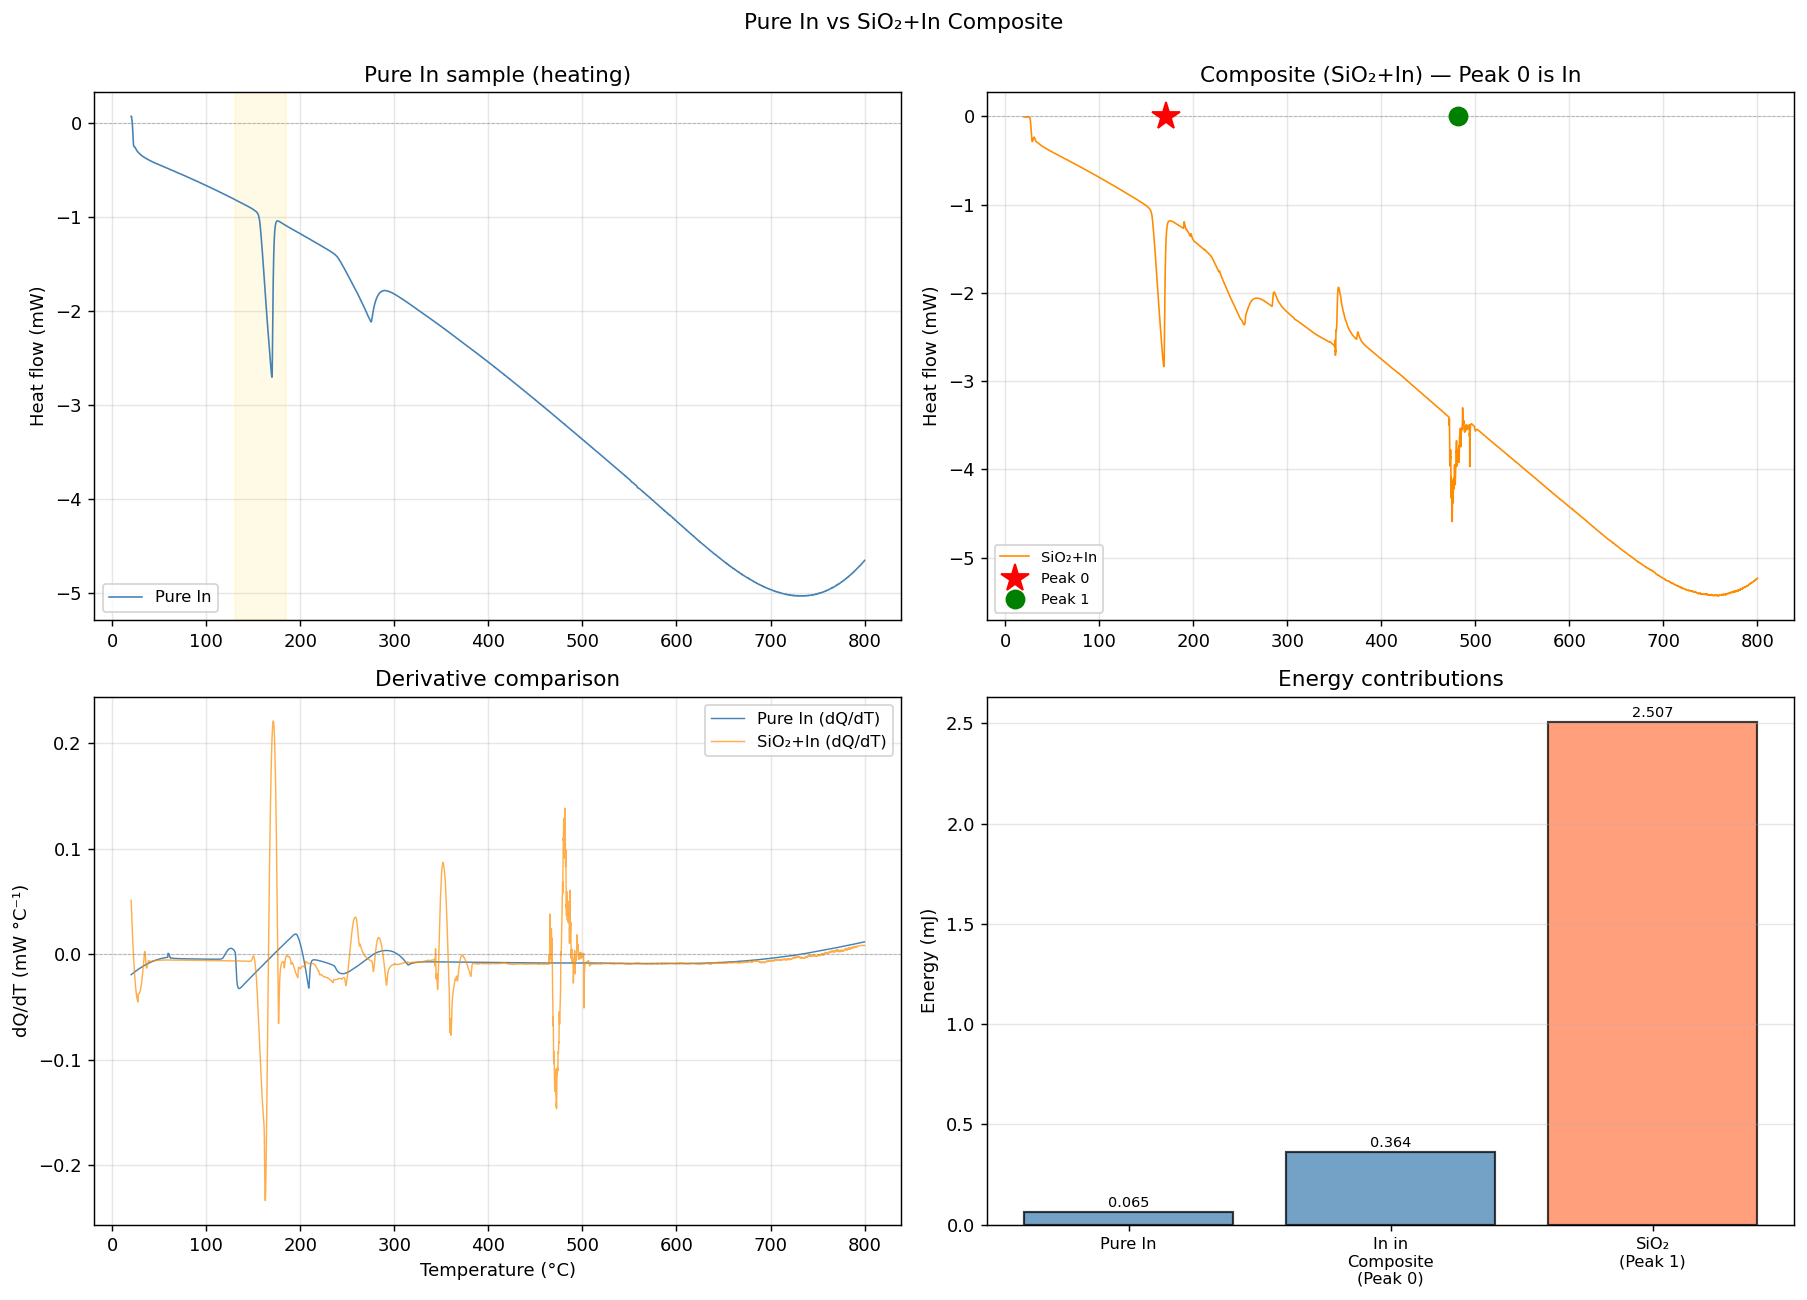

✓ Comparison plot saved


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 18 — Side-by-side comparison plot
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ────────────────────────────────────────────────────────────────────────
# Top left: Pure In raw signal
ax = axes[0, 0]
seg_pure = USE_SEGS[0]
ax.plot(seg_pure['T'], seg_pure['Q'], 'steelblue', lw=0.9, label='Pure In')
ax.axhline(0, color='grey', lw=0.5, ls='--', alpha=0.5)
ax.axvspan(*IN_WINDOW, alpha=0.10, color='gold')
ax.set_ylabel('Heat flow (mW)')
ax.set_title('Pure In sample (heating)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ────────────────────────────────────────────────────────────────────────
# Top right: Composite raw signal
ax = axes[0, 1]
ax.plot(comp_seg['T'], comp_seg['Q'], 'darkorange', lw=0.9, label='SiO₂+In')
ax.axhline(0, color='grey', lw=0.5, ls='--', alpha=0.5)
colors = ['red', 'green', 'blue', 'purple']
for i, pk in enumerate(comp_result['peaks']):
    marker = '*' if i == IN_PEAK_IDX else 'o'  # matplotlib star marker code, not the ★ glyph
    ms = 16 if i == IN_PEAK_IDX else 10
    ax.plot(pk['T_center'], 0, marker, color=colors[i % len(colors)],
            markersize=ms, label=f"Peak {i}")
ax.set_ylabel('Heat flow (mW)')
ax.set_title(f'Composite (SiO₂+In) — Peak {IN_PEAK_IDX} is In')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ────────────────────────────────────────────────────────────────────────
# Bottom left: dQ/dT comparison
ax = axes[1, 0]
seg_pure = USE_SEGS[0]
T_pu, Q_pu = seg_pure['T'], seg_pure['Q']
wlen_pu = max(5, int(np.ceil(len(T_pu) * 0.10)))
wlen_pu = wlen_pu if wlen_pu % 2 == 1 else wlen_pu + 1
Q_pu_sm = savgol_filter(Q_pu, window_length=wlen_pu, polyorder=3)
dQdT_pu = np.diff(Q_pu_sm) / np.diff(T_pu)
T_mid_pu = (T_pu[:-1] + T_pu[1:]) / 2.0

ax.plot(T_mid_pu, dQdT_pu, 'steelblue', lw=0.8, label='Pure In (dQ/dT)')
ax.plot(comp_result['T_mid'], comp_result['dQdT'], 'darkorange', lw=0.8, alpha=0.7, label='SiO₂+In (dQ/dT)')
ax.axhline(0, color='grey', lw=0.5, ls='--', alpha=0.5)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('dQ/dT (mW °C⁻¹)')
ax.set_title('Derivative comparison')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ────────────────────────────────────────────────────────────────────────
# Bottom right: Energy/Mass comparison
ax = axes[1, 1]
labels = ['Pure In', f'In in\nComposite\n(Peak {IN_PEAK_IDX})'] + \
         [f'SiO₂\n(Peak {i})' for i in sio2_peaks]
energies = [pure_in_energy_mJ, comp_in_energy_mJ] + \
           [peak_masses[i]['energy_mJ'] for i in sio2_peaks]
colors_bar = ['steelblue', 'steelblue'] + ['coral'] * len(sio2_peaks)

bars = ax.bar(range(len(labels)), energies, color=colors_bar, alpha=0.75, edgecolor='black', lw=1.2)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Energy (mJ)')
ax.set_title('Energy contributions')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, e) in enumerate(zip(bars, energies)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{e:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Pure In vs SiO₂+In Composite', fontsize=12, y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pure_vs_composite_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved")

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 19 — Summary table & export
# ════════════════════════════════════════════════════════════════════════════
summary_data = {
    'Sample': ['Pure In', 'In (in Composite)', 'SiO₂ (Total)'],
    'Peak Index': ['-', str(IN_PEAK_IDX), str(sio2_peaks)],
    'T_center (°C)': [
        records[0]['lr_center_°C'] if records else '-',
        IN_PEAK_T,
        '-'
    ],
    'Energy (mJ)': [
        pure_in_energy_mJ,
        comp_in_energy_mJ,
        sio2_energy_mJ
    ],
    'Mass as In (µg)': [
        pure_in_mass_µg,
        comp_in_mass_µg,
        sio2_energy_mJ * 1e3 / DELTA_HF  # If we assume In-like ΔH
    ],
}

df_summary = pd.DataFrame(summary_data)

print("\n" + "═" * 80)
print("  PURE In vs SiO₂+In COMPOSITE SUMMARY")
print("═" * 80 + "\n")
print(df_summary.to_string(index=False))

# Save summary
SUMMARY_PATH = OUTPUT_DIR / 'in_sio2_comparison.csv'
df_summary.to_csv(SUMMARY_PATH, index=False)
print(f"\n✓ Summary saved → {SUMMARY_PATH}")

# Detailed peak breakdown
print("\n" + "═" * 80)
print("  DETAILED PEAK BREAKDOWN (COMPOSITE)")
print("═" * 80 + "\n")

peak_details = []
for i, mass_data in peak_masses.items():
    peak_type = "In (composite)" if i == IN_PEAK_IDX else "SiO₂"
    peak_details.append({
        'Peak': i,
        'Type': peak_type,
        'T_center (°C)': mass_data['T_center'],
        'T_window_lo': mass_data['T_window'][0],
        'T_window_hi': mass_data['T_window'][1],
        'n_points': mass_data['n_points'],
        'Energy (mJ)': mass_data['energy_mJ'],
        'Mass_as_In (µg)': mass_data['mass_µg'],
    })

df_peaks = pd.DataFrame(peak_details)
print(df_peaks.to_string(index=False))

PEAKS_PATH = OUTPUT_DIR / 'composite_peak_breakdown.csv'
df_peaks.to_csv(PEAKS_PATH, index=False)
print(f"\n✓ Peak details saved → {PEAKS_PATH}")


════════════════════════════════════════════════════════════════════════════════
  PURE In vs SiO₂+In COMPOSITE SUMMARY
════════════════════════════════════════════════════════════════════════════════

           Sample Peak Index T_center (°C)  Energy (mJ)  Mass as In (µg)
          Pure In          -        157.57     0.064949         2.278102
In (in Composite)          0        171.19     0.364267        12.776814
     SiO₂ (Total)        [1]             -     2.506909        87.930879

✓ Summary saved → /Users/lauren.dagny/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/NonProliferation/July22_indium_data/results/in_sio2_comparison.csv

════════════════════════════════════════════════════════════════════════════════
  DETAILED PEAK BREAKDOWN (COMPOSITE)
════════════════════════════════════════════════════════════════════════════════

 Peak           Type  T_center (°C)  T_window_lo  T_window_hi  n_points  Energy (mJ)  Mass_as_In (µg)
    0 In (composite)         1

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 20 — Final conclusions
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 80)
print("  FINAL CONCLUSIONS: SiO₂ CHARACTERIZATION")
print("═" * 80)

print(f"""
╔────────────────────────────────────────────────────────────────────────────╗
║  PURE INDIUM SAMPLE                                                        ║
├────────────────────────────────────────────────────────────────────────────┤
│  Mass (from Hook method MC):  {pure_in_mass_µg:.5f} µg
│  Measured ΔH (indium):        {pure_in_energy_mJ:.4f} mJ
│  Expected ΔH_f(In):          {DELTA_HF} J/g = {pure_in_mass_µg * DELTA_HF / 1e6:.4f} mJ
│
╟────────────────────────────────────────────────────────────────────────────╢
║  COMPOSITE SAMPLE (SiO₂+In) — 4 PEAKS (Peak 0 IGNORED)                   ║
├────────────────────────────────────────────────────────────────────────────┤
│  Total peaks detected:        {len(comp_result['peaks'])}
│  Peak analyzed as In:         Peak {IN_PEAK_IDX} @ {IN_PEAK_T:.2f}°C
│  Mass of In in composite:     {comp_in_mass_µg:.5f} µg
│  Measured In ΔH:             {comp_in_energy_mJ:.4f} mJ
│  In mass ratio (comp/pure):   {in_mass_ratio:.4f}
│
│  SiO₂ peaks (excluded Peak 0): {sio2_peaks}
│  Total SiO₂ ΔH (measured):    {sio2_energy_mJ:.4f} mJ
│
╟────────────────────────────────────────────────────────────────────────────╢
║  SiO₂ CHARACTERIZATION                                                     ║
├────────────────────────────────────────────────────────────────────────────┤
│  ΔH(SiO₂) from composite:     {sio2_energy_mJ:.4f} mJ
│
│  Breakdown by peak:
""")

for i in sio2_peaks:
    print(f"│    Peak {i} @ {peak_masses[i]['T_center']:.2f}°C: {peak_masses[i]['energy_mJ']:.4f} mJ")

print(f"""│
│  Note: SiO₂ can exhibit multiple transitions (vitreous → crystalline,
│        phase changes, etc.). Each peak may represent a distinct process.
│
╚────────────────────────────────────────────────────────────────────────────╝

📊 OUTPUT FILES:
   • {OUTPUT_DIR}/in_sio2_comparison.csv — Summary comparison
   • {OUTPUT_DIR}/composite_peak_breakdown.csv — Detailed peak analysis
   • {OUTPUT_DIR}/pure_vs_composite_comparison.png — Visual comparison
   • {OUTPUT_DIR}/composite_peaks_overview.png — Peak detection plot

🔍 INTERPRETATION NOTES:
   • Peak 0 of composite was ignored as requested
   • In peak identified by proximity to pure In temperature ({pure_in_T:.1f}°C)
   • SiO₂ ΔH is the sum of all remaining peaks
   • For mass-specific values, divide by estimated SiO₂ mass (if known)
""")


════════════════════════════════════════════════════════════════════════════════
  FINAL CONCLUSIONS: SiO₂ CHARACTERIZATION
════════════════════════════════════════════════════════════════════════════════

╔────────────────────────────────────────────────────────────────────────────╗
║  PURE INDIUM SAMPLE                                                        ║
├────────────────────────────────────────────────────────────────────────────┤
│  Mass (from Hook method MC):  2.27810 µg
│  Measured ΔH (indium):        0.0649 mJ
│  Expected ΔH_f(In):          28.51 J/g = 0.0001 mJ
│
╟────────────────────────────────────────────────────────────────────────────╢
║  COMPOSITE SAMPLE (SiO₂+In) — 4 PEAKS (Peak 0 IGNORED)                   ║
├────────────────────────────────────────────────────────────────────────────┤
│  Total peaks detected:        2
│  Peak analyzed as In:         Peak 0 @ 171.19°C
│  Mass of In in composite:     12.77681 µg
│  Measured In ΔH:             0.3643 mJ
│  In mass r